**Task 1:**
Classification Using K-Nearest Neighbour Classifier.

**1- Libraries Imports:**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import math
import warnings
import scipy.stats
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

**2- Data Preprocessing:**
- Reading the data
- Splitting the two classes
- Removing extra data
- Split features and target

In [2]:
data = pd.read_csv("magic04.data", header= None)
print(data.head())

         0         1       2       3       4         5        6        7   \
0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110  -8.2027   
1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238  -9.9574   
2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580 -45.2160   
3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633  -7.1513   
4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525  21.8393   

        8         9  10  
0  40.0920   81.8828  g  
1   6.3609  205.2610  g  
2  76.9600  256.7880  g  
3  10.4490  116.7370  g  
4   4.6480  356.4620  g  


In [3]:
data.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
dtype: int64

In [4]:
gamma = data[data[10] == 'g']
hadron =  data[data[10] == 'h']
print(f"gammas = {len(gamma)}")
print(f"hadrons = {len(hadron)}")

gammas = 12332
hadrons = 6688


In [5]:
gamma_sampled = gamma.sample(n=len(hadron), random_state=42)

print(f"gammas = {len(gamma_sampled)}")
print(f"hadrons = {len(hadron)}")

balanced_data = pd.concat([gamma_sampled, hadron])

gammas = 6688
hadrons = 6688


In [6]:
features = balanced_data.drop(columns=[10])
target = balanced_data[10]

**3- Data Splitting:**
- Split data to 70% train, 15% validation, and 15% test.

In [7]:
features_train, features_temp, target_train, target_temp = train_test_split(
    features,
    target,
    test_size= 0.3,
    shuffle= True,
    random_state= 42
)

In [8]:
features_test, features_validation, target_test, target_validation = train_test_split(
    features_temp,
    target_temp,
    test_size= 0.5,
    shuffle= True,
    random_state= 42
)

In [9]:
print(f"Length of train samples = {len(features_train)}")
print(f"Length of test samples = {len(features_validation)}")
print(f"Length of validation samples = {len(features_test)}")

Length of train samples = 9363
Length of test samples = 2007
Length of validation samples = 2006


**4- Apply K-NN Classifier to the data**  
We will apply K-Nearest Neighbour in 2 ways (self-written functions & using libraries)
In each method we will:
- Apply k = sqrt(n) "Common Heuristic".
- Apply different k values to get the best results.

1 - Self-written

In [10]:
def eculidean_distance (x,y):
    distance = np.linalg.norm(x-y, axis=1)
    return distance

In [11]:
def KNN(new_data_point, X = features_train.values, Y = target_train.values, k= int(round(math.sqrt(len(features_train))))):
    distances = eculidean_distance(X, new_data_point)
    nearest_neighbor_ids = distances.argsort()[:k]
    nearest_neighbor_target = Y[nearest_neighbor_ids]
    prediction = scipy.stats.mode(nearest_neighbor_target)[0]
    return prediction

In [12]:
validation_predict_sqrt = np.array([KNN(x) for x in features_validation.values])
validation_accuracy_sqrt = accuracy_score(target_validation, validation_predict_sqrt)
print(f"Validation Accuracy - Self-written function KNN (k=sqrt(n)): {validation_accuracy_sqrt:.2f}")

Validation Accuracy - Self-written function KNN (k=sqrt(n)): 0.76


2 - Using library sklearn

In [13]:
k = int(round(math.sqrt(len(features_train))))
print (f"k = {k}")

sqrtk_model = KNeighborsClassifier(n_neighbors= k)
sqrtk_model.fit(features_train, target_train)

validation_predict_sqrtsklearn = sqrtk_model.predict(features_validation)
validation_accuracy_sqrtsklearn = accuracy_score(target_validation, validation_predict_sqrtsklearn)
print(f"Validation Accuracy - sklearn KNN (k=sqrt(n)): {validation_accuracy_sqrtsklearn:.2f}")

k = 97
Validation Accuracy - sklearn KNN (k=sqrt(n)): 0.76


Applying different K to get the best in both models:

In [14]:
k_values = range(1, int(round(math.sqrt(len(features_train)))))
accuracies_without_sklearn = []
accuracies_sklearn = []

for k in k_values:

    # 1 - sklearn
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(features_train, target_train)
    y_pred_sklearn = model.predict(features_validation)
    accuracies_sklearn.append(accuracy_score(target_validation, y_pred_sklearn))

    # 2 - self-written function
    y_pred_without_sklearn = np.array([KNN(x , k= k) for x in features_validation.values])
    accuracies_without_sklearn.append(accuracy_score(target_validation, y_pred_without_sklearn))


In [15]:
best_k_without_sklearn = k_values[accuracies_without_sklearn.index(max(accuracies_without_sklearn))]
best_k_sklearn = k_values[accuracies_sklearn.index(max(accuracies_sklearn))]

print(f"Best K - sklearn: {best_k_sklearn}, Accuracy: {max(accuracies_sklearn):.2f}")
print(f"Best K - without sklearn: {best_k_without_sklearn}, Accuracy: {max(accuracies_without_sklearn):.2f}")

Best K - sklearn: 48, Accuracy: 0.77
Best K - without sklearn: 60, Accuracy: 0.77


**Reporting Results**  
1- Validation accuracy over different K values without sklearn:

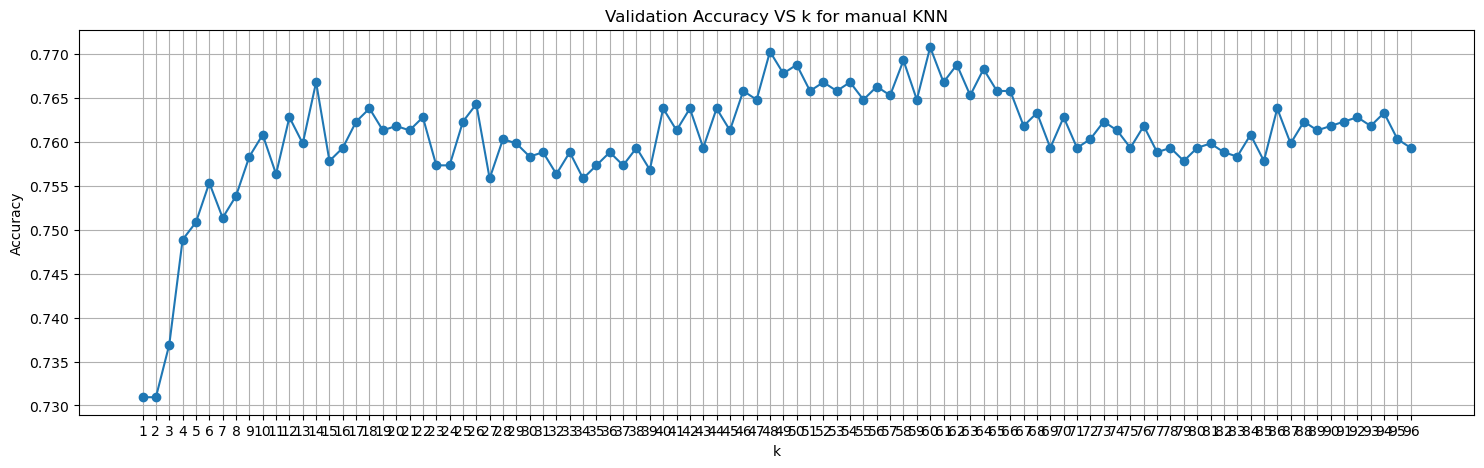

In [16]:
plt.figure(figsize=(18,5))
plt.plot(k_values, accuracies_without_sklearn, marker='o')
plt.title('Validation Accuracy VS k for manual KNN')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.show()

2- Validation accuracy over different K values with sklearn:

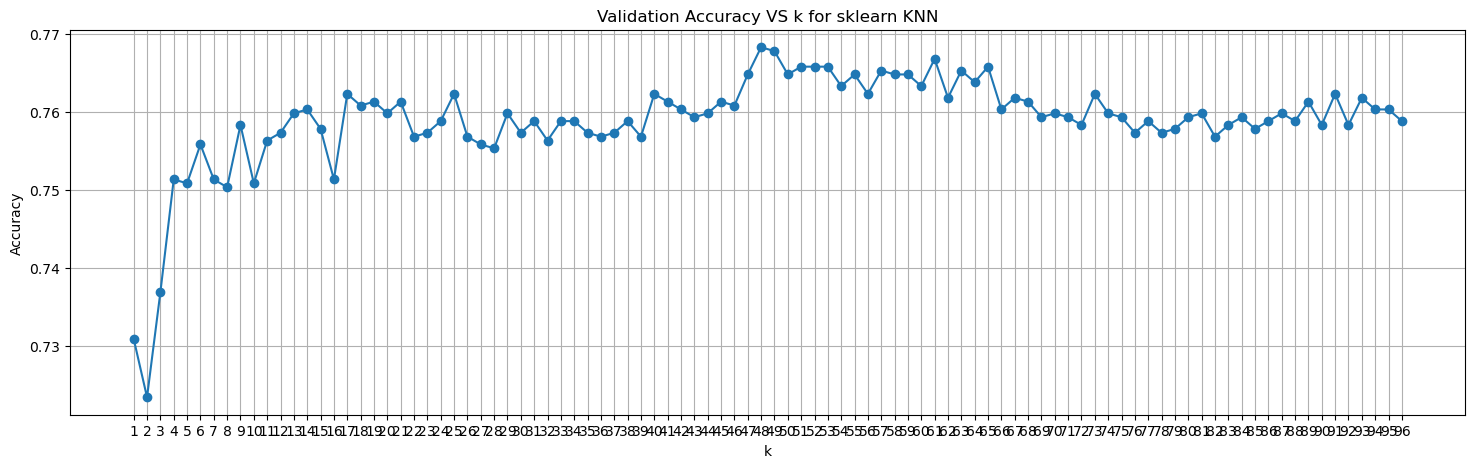

In [17]:
plt.figure(figsize=(18,5))
plt.plot(k_values, accuracies_sklearn, marker='o')
plt.title('Validation Accuracy VS k for sklearn KNN')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.show()

#It is noticed that nearly both models' accuracies are the same except that the sklearn model is slightly faster.
Since the difference between accuracies is less than 0.01 in the interval k = [17 : 55], we can assume that optimal K lies somewhere in between these values.

3 - Test accuracy for the optimal K without sklearn

In [18]:
y_pred_test_without_sklearn = np.array([KNN(x , k= best_k_without_sklearn) for x in features_test.values])
print(f"Accuracy = {accuracy_score(target_test, y_pred_test_without_sklearn)}")

Accuracy = 0.7731804586241277


4 - Test accuracy for the optimal K with sklearn

In [19]:
model_with_bestK = KNeighborsClassifier(n_neighbors=best_k_sklearn)
model_with_bestK.fit(features_train, target_train)
y_pred_test_sklearn = model.predict(features_test)
print(f"Accuracy = {accuracy_score(target_test, y_pred_test_sklearn)}")

Accuracy = 0.7627118644067796


#It is noticed that the accuracy of the best K in hand-written model is slightly better than sklearn

5 - Calculating Percision without sklearn

In [20]:
precision_manual = precision_score(target_test, y_pred_test_without_sklearn, pos_label='g')
print(f"Precision = {precision_manual:.2f}")

Precision = 0.72


5 - Calculating Percision with sklearn

In [21]:
precision_model = precision_score(target_test, y_pred_test_sklearn, pos_label='g')
print(f"Precision = {precision_model:.2f}")

Precision = 0.71


#It is noticed that the hand-written system avoids false classification more

6 - Calculating Recall without sklearn

In [22]:
recall_manual=recall_score(target_test, y_pred_test_without_sklearn, pos_label='g')
print(f"Recall: {recall_manual:.2f}")

Recall: 0.89


7 - Calculating Recall with sklearn

In [23]:
recall_sklearn=recall_score(target_test, y_pred_test_sklearn, pos_label='g')
print(f"Recall: {recall_sklearn:.2f}")

Recall: 0.90


#It is noticed that the sklearn model tends to not miss positives more

8 - Calculating f-score for manual model

In [24]:
f_manual=f1_score(target_test, y_pred_test_without_sklearn, pos_label='g')
print(f"f-score: {f_manual:.2f}")

f-score: 0.80


9 - Calculating f-score for sklearn model

In [25]:
f_sklearn=f1_score(target_test, y_pred_test_sklearn, pos_label='g')
print(f"f-score: {f_sklearn:.2f}")

f-score: 0.79


10 - Confusion Matrix for manual model

In [26]:
print("Confusion matrix:")
print(confusion_matrix(target_test, y_pred_test_without_sklearn))

Confusion matrix:
[[903 111]
 [344 648]]


11 - Confusion Matrix for sklearn model

In [27]:
print("Confusion matrix:")
print(confusion_matrix(target_test, y_pred_test_sklearn))

Confusion matrix:
[[911 103]
 [373 619]]


#Overall : both models are very similar with small percentage of errors.

**Regression Part**

In [28]:
# Load dataset
df = pd.read_csv("California_Houses.csv")
df = df.fillna(df.median())  # fill missing values

# we remove this column from the dataset because it is the target we want to predict.
# .values → converts the DataFrame into a NumPy array for faster and easier calculations.
X = df.drop("Median_House_Value", axis=1).values

# Target variable -> the values the model is supposed to learn and predict.
#.values.reshape(-1,1) → reshapes it from (20640,) to (20640, 1) so it is compatible with matrix operations.
y = df["Median_House_Value"].values.reshape(-1, 1)

# Add bias column for manual regression
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Split dataset: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# Normalize features (except bias column)
scaler = StandardScaler()
X_train[:,1:] = scaler.fit_transform(X_train[:,1:])
X_val[:,1:] = scaler.transform(X_val[:,1:])
X_test[:,1:] = scaler.transform(X_test[:,1:])

Train: (14448, 14)
Validation: (3096, 14)
Test: (3096, 14)


In [29]:
# Normal Equation function
def normal_eq(X, y):
    # Normal Equation: w = (X^T X)^(-1) X^T 
    return np.linalg.inv(X.T @ X) @ X.T @ y

# Calculate weights
w_linear = normal_eq(X_train, y_train)

# Predictions
y_pred_manual = X_test @ w_linear

In [30]:
def ridge_normal_eq(X, y, lam):
    n, f = X.shape
    I = np.identity(f)
    return np.linalg.inv(X.T @ X + lam * n * I) @ X.T @ y

w_ridge_manual = ridge_normal_eq(X_train, y_train, lam=0.001)
y_pred_ridge_manual = X_test @ w_ridge_manual

In [31]:
# Lasso using gradient descent
def lasso_gd(X, y, lam=0.001, alpha=0.01, epochs=1000):
    n, f = X.shape
    w = np.zeros((f,1))  # initialize weights
    
    for i in range(epochs):
        grad = X.T @ (X @ w - y)  # gradient of MSE
        # update with L1 regularization
        w = w - (alpha / n) * (grad + lam * np.sign(w)) 
    return w

# Calculate Lasso weights
w_lasso_manual = lasso_gd(X_train, y_train, lam=0.001, alpha=0.01, epochs=5000)

# Predictions
y_pred_lasso_manual = X_test @ w_lasso_manual

In [32]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train[:,1:], y_train)  # skip bias column for sklearn
y_pred_sklearn_linear = linear_model.predict(X_test[:,1:])

# Ridge Regression
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train[:,1:], y_train)
y_pred_sklearn_ridge = ridge_model.predict(X_test[:,1:])

# Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train[:,1:], y_train)
y_pred_sklearn_lasso = lasso_model.predict(X_test[:,1:])

In [33]:
# Compare all models
results = pd.DataFrame({
    "Model": ["Manual Linear", "Sklearn Linear", "Manual Ridge", "Sklearn Ridge", "Manual Lasso", "Sklearn Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred_manual),
        mean_squared_error(y_test, y_pred_sklearn_linear),
        mean_squared_error(y_test, y_pred_ridge_manual),
        mean_squared_error(y_test, y_pred_sklearn_ridge),
        mean_squared_error(y_test, y_pred_lasso_manual),
        mean_squared_error(y_test, y_pred_sklearn_lasso)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_manual),
        mean_absolute_error(y_test, y_pred_sklearn_linear),
        mean_absolute_error(y_test, y_pred_ridge_manual),
        mean_absolute_error(y_test, y_pred_sklearn_ridge),
        mean_absolute_error(y_test, y_pred_lasso_manual),
        mean_absolute_error(y_test, y_pred_sklearn_lasso)
    ]
})

results

,Model,MSE,MAE
0,Manual Linear,4.400953e+09,48782.031081
1,Sklearn Linear,4.400953e+09,48782.031081
2,Manual Ridge,4.399464e+09,48805.389393
3,Sklearn Ridge,4.400953e+09,48782.033312
4,Manual Lasso,4.427993e+09,49173.967087
5,Sklearn Lasso,4.400953e+09,48782.031545
